# LoRA Fine-Tuning: Phi-4 Mini Instruct on MedMCQA

**Research Study:** Assessing Fine-Tuning Strategies for Medical Question Answering

**Method:** LoRA (Low-Rank Adaptation) — full bf16/fp16 base model with low-rank adapter matrices injected into attention layers. Unlike QLoRA, the base model is NOT quantized, so higher VRAM is required but precision is preserved.

**Key differences vs QLoRA notebook:**
- No `BitsAndBytesConfig` / 4-bit quantization
- No `prepare_model_for_kbit_training`
- Base model loaded in `bfloat16` (full precision)
- `bf16=True` in TrainingArguments (A100) or `fp16=True` (T4)
- Higher memory usage — recommend A100 (40 GB) or at minimum T4 (16 GB) with reduced batch size

**Model:** `microsoft/Phi-4-mini-instruct`  
**Dataset:** `openlifescienceai/medmcqa`

##Install Dependencies

In [ ]:
# ============================================================
# 1 — Install Dependencies
# LoRA does NOT require bitsandbytes for quantization
# but we keep it installed as it is a transitive dependency
# of some trl/peft versions.
# ============================================================
#!pip install -q transformers==4.47.0
!pip install -q transformers==4.48.0
!pip install -q peft==0.14.0
!pip install -q trl==0.13.0
!pip install -q datasets==3.2.0
!pip install -q accelerate==1.2.1
!pip install -q wandb
!pip install -q scikit-learn
!pip install -q evaluate

# Uninstall bitsandbytes entirely — LoRA uses full bf16 precision,
# no quantization needed, and bnb causes triton import crashes on some runtimes
!pip uninstall -y bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 165.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.4/293.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 22.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━

##Imports & GPU Check

In [ ]:
# ============================================================
# 2 — Imports & GPU / VRAM Check
# ============================================================
import os
import json
import time
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)
from tqdm import tqdm

# ── GPU diagnostics ──────────────────────────────────────────
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU             : {gpu}")
    print(f"VRAM (total)    : {vram_total:.1f} GB")

    # LoRA VRAM guidance
    if vram_total >= 35:
        print("✅  A100 detected — bf16 training recommended.")
    elif vram_total >= 14:
        print("T4/V100 detected — use fp16=True and reduce per_device_train_batch_size to 1.")
    else:
        print("Less than 14 GB VRAM — LoRA on Phi-4 Mini may OOM. Consider QLoRA instead.")
else:
    print("No GPU detected — training will be very slow.")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA A100-SXM4-80GB
VRAM (total)    : 85.1 GB
✅  A100 detected — bf16 training recommended.


##Mount Google Drive & Define Paths

In [ ]:
# ============================================================
# 3 — Mount Google Drive & Define All Paths
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

# ── Base directory (mirrors QLoRA structure, method = lora) ──
BASE_DIR     = "/content/drive/MyDrive/phi4_medmcqa"

# ── LoRA-specific output paths ────────────────────────────────
LORA_SAVE_DIR     = os.path.join(BASE_DIR, "lora_adapter_2")    # trained adapter weights
LORA_FINAL_DIR    = os.path.join(BASE_DIR, "lora_final_2")      # merged / final adapter
LORA_LOG_DIR      = os.path.join(BASE_DIR, "lora_logs_2")       # TensorBoard logs
METRICS_DIR       = os.path.join(BASE_DIR, "metrics_lora_2")    # evaluation JSON files
CHECKPOINT_DIR    = os.path.join(BASE_DIR, "lora_checkpoints_2")# intermediate checkpoints

for d in [LORA_SAVE_DIR, LORA_FINAL_DIR, LORA_LOG_DIR, METRICS_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)

print("All directories created/verified:")
for d in [LORA_SAVE_DIR, LORA_FINAL_DIR, LORA_LOG_DIR, METRICS_DIR, CHECKPOINT_DIR]:
    print(" ", d)

Mounted at /content/drive
All directories created/verified:
  /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2
  /content/drive/MyDrive/phi4_medmcqa/lora_final_2
  /content/drive/MyDrive/phi4_medmcqa/lora_logs_2
  /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2
  /content/drive/MyDrive/phi4_medmcqa/lora_checkpoints_2


##Load & Preprocess MedMCQA Dataset

In [ ]:
# ============================================================
# 4 — Load, Filter, Format & Sample MedMCQA Dataset
# ============================================================

print("Loading MedMCQA dataset...")
raw_dataset = load_dataset("openlifescienceai/medmcqa")
print(raw_dataset)

# ── Inspect a sample ─────────────────────────────────────────
sample = raw_dataset["train"][0]
print("\nSample record:")
for k, v in sample.items():
    print(f"  {k}: {v}")

# ── Filter: keep only rows with all four options & valid cop ──
def is_valid(example):
    return (
        example["question"] and
        example["opa"] and example["opb"] and
        example["opc"] and example["opd"] and
        example["cop"] in [0, 1, 2, 3]
    )

filtered = raw_dataset.filter(is_valid)
print(f"\nAfter filtering:")
print(f"  Train      : {len(filtered['train'])}")
print(f"  Validation : {len(filtered['validation'])}")
print(f"  Test       : {len(filtered['test'])}")

# ── Format into instruction-response prompts ─────────────────
label_map = {0: "A", 1: "B", 2: "C", 3: "D"}

def format_prompt(example):
    answer_letter = label_map[example["cop"]]
    text = (
        "You are a medical expert answering a multiple choice medical question.\n"
        "Read the question carefully and select the single best option.\n"
        "Reply with only one letter: A, B, C, or D.\n\n"
        f"Question: {example['question']}\n\n"
        "Options:\n"
        f"A) {example['opa']}\n"
        f"B) {example['opb']}\n"
        f"C) {example['opc']}\n"
        f"D) {example['opd']}\n\n"
        f"Answer: {answer_letter}"
    )
    return {"text": text}

formatted_dataset = filtered.map(format_prompt)
print("\nFormatting done. Columns:", formatted_dataset["train"].column_names)

# ── Sample selection — matches QLoRA exactly ─────────────────
train_sample = formatted_dataset["train"].shuffle(seed=42).select(range(30000))  # Iteration 1
#train_sample = formatted_dataset["train"].shuffle(seed=42).select(range(60000))   # Iteration 2
eval_sample  = formatted_dataset["validation"].shuffle(seed=42).select(range(1000))

print(f"\nTrain sample size : {len(train_sample)}")
print(f"Eval sample size  : {len(eval_sample)}")
print(f"\nSample text field :\n{train_sample[0]['text']}")

Loading MedMCQA dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

...

Filter:   0%|          | 0/4183 [00:00<?, ? examples/s]


After filtering:
  Train      : 182822
  Validation : 4183
  Test       : 0


Map:   0%|          | 0/182822 [00:00<?, ? examples/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]


Formatting done. Columns: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name', 'text']

Train sample size : 30000
Eval sample size  : 1000

Sample text field :
You are a medical expert answering a multiple choice medical question.
Read the question carefully and select the single best option.
Reply with only one letter: A, B, C, or D.

Question: OPV can be used if vaccine l monitor is showing?

Options:
A) Colour of outer circle is same as inner square
B) Colour of outer circle is darker than inner square
C) Colour of outer circle is lighter than inner square
D) None of the above

Answer: B


##Prompt Formatter

In [ ]:
# ============================================================
# 5 — Instruction-Response Prompt Formatter
# Same prompt structure as QLoRA for a fair comparison.
# ============================================================

label_map = {0: "A", 1: "B", 2: "C", 3: "D"}

def format_prompt(example):
    """
    Converts a MedMCQA record into an instruction-response
    prompt string suitable for Phi-4 Mini Instruct SFT.
    """
    answer_letter = label_map[example["cop"]]

    prompt = (
        "You are a medical expert answering a multiple choice medical question.\n"
        "Read the question carefully and select the single best option.\n"
        "Reply with only one letter: A, B, C, or D.\n\n"
        f"Question: {example['question']}\n\n"
        "Options:\n"
        f"A) {example['opa']}\n"
        f"B) {example['opb']}\n"
        f"C) {example['opc']}\n"
        f"D) {example['opd']}\n\n"
        f"Answer: {answer_letter}"
    )
    return {"text": prompt}

# Apply formatter
train_data = filtered["train"].map(format_prompt, remove_columns=filtered["train"].column_names)
val_data   = filtered["validation"].map(format_prompt, remove_columns=filtered["validation"].column_names)
test_data  = filtered["test"].map(format_prompt, remove_columns=filtered["test"].column_names)

print(f"Formatted splits — Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("\nExample formatted prompt:")
print(train_data[0]["text"])

Map:   0%|          | 0/182822 [00:00<?, ? examples/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

Formatted splits — Train: 182822 | Val: 4183 | Test: 0

Example formatted prompt:
You are a medical expert answering a multiple choice medical question.
Read the question carefully and select the single best option.
Reply with only one letter: A, B, C, or D.

Question: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma

Options:
A) Hyperplasia
B) Hyperophy
C) Atrophy
D) Dyplasia

Answer: C


##Load Tokenizer

In [ ]:
# ============================================================
# 6 — Load Tokenizer
# Identical to QLoRA — tokenizer is model-specific,
# not affected by the fine-tuning method.
# ============================================================

MODEL_ID = "microsoft/Phi-4-mini-instruct"

print(f"Loading tokenizer from: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)

# Phi-4 Mini does not define a pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

tokenizer.padding_side = "right"   # required for causal LM training

print(f"Vocab size       : {tokenizer.vocab_size}")
print(f"Model max length : {tokenizer.model_max_length}")
print(f"Pad token        : {tokenizer.pad_token}  (id={tokenizer.pad_token_id})")
print(f"EOS token        : {tokenizer.eos_token}  (id={tokenizer.eos_token_id})")

Loading tokenizer from: microsoft/Phi-4-mini-instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

Vocab size       : 200019
Model max length : 131072
Pad token        : <|endoftext|>  (id=199999)
EOS token        : <|endoftext|>  (id=199999)


##Load Base Model in bf16 (LoRA — NO Quantization)

In [ ]:
# ============================================================
# 7 — Load Base Model in bf16  ← KEY DIFFERENCE vs QLoRA
# ============================================================
#
# QLoRA: loads model in 4-bit (NF4) via BitsAndBytesConfig
#        → ~4 GB VRAM for Phi-4 Mini
#
# LoRA:  loads model in full bfloat16 (no quantization)
#        → ~8–10 GB VRAM for Phi-4 Mini (3.8 B params × 2 bytes)
#        → Requires A100 or T4 with small batch size
#
# NOTE: We do NOT call prepare_model_for_kbit_training() here
#       because the base model is not quantized.
# ============================================================

print(f"Loading {MODEL_ID} in bfloat16 (full precision, no quantization)...")
print("Expected VRAM usage: ~8–10 GB for Phi-4 Mini (3.8 B params)")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,      # bf16 full precision (use float16 on T4)
    device_map="auto",               # auto-distribute across available GPUs
    trust_remote_code=True,
    # ── No BitsAndBytesConfig here — this is the LoRA branch ──
)

# Enable gradient checkpointing to reduce VRAM at the cost of speed
base_model.gradient_checkpointing_enable()

# Required when gradient checkpointing is enabled
base_model.enable_input_require_grads()

# Print parameter count
total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nTotal parameters : {total_params / 1e9:.2f} B")
print(f"Model dtype      : {next(base_model.parameters()).dtype}")

# VRAM after loading
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    print(f"\nVRAM allocated after model load : {allocated:.2f} GB")
    print(f"VRAM reserved  after model load : {reserved:.2f} GB")

Loading microsoft/Phi-4-mini-instruct in bfloat16 (full precision, no quantization)...
Expected VRAM usage: ~8–10 GB for Phi-4 Mini (3.8 B params)


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]


Total parameters : 3.84 B
Model dtype      : torch.bfloat16

VRAM allocated after model load : 7.67 GB
VRAM reserved  after model load : 7.68 GB


##Configure LoRA Adapter

In [ ]:
# ============================================================
# 8 — Configure LoRA Adapter
# ============================================================
#
# Hyperparameters kept IDENTICAL to QLoRA for a fair
# experimental comparison (same r, alpha, dropout, modules).
#
# LoRA injects trainable low-rank matrices A and B into
# selected linear layers such that:
#   W' = W + (alpha/r) * B @ A
# Only A and B are updated; W remains frozen.
# ============================================================

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,

    # ── Rank & scaling ──────────────────────────────────────
    r=16,                  # rank of the low-rank matrices
    lora_alpha=32,         # scaling factor (effective lr scale = alpha/r = 2.0)

    # ── Regularisation ──────────────────────────────────────
    lora_dropout=0.05,     # dropout on adapter outputs

    # ── Target modules ──────────────────────────────────────
    # Phi-4 Mini uses standard attention projection names.
    # Including gate/up/down proj covers the MLP layers too.
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    # ── Bias handling ────────────────────────────────────────
    bias="none",           # do not train bias terms

    # ── Inference mode ──────────────────────────────────────
    inference_mode=False,  # training mode
)

# Wrap the base model with LoRA adapters
lora_model = get_peft_model(base_model, lora_config)

# ── Trainable parameter summary ──────────────────────────────
lora_model.print_trainable_parameters()

# Manually compute the percentage for logging
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in lora_model.parameters())
print(f"\nTrainable params : {trainable:,}  ({100*trainable/all_params:.2f}% of total)")
print(f"Frozen params    : {all_params - trainable:,}")

trainable params: 8,912,896 || all params: 3,844,934,656 || trainable%: 0.2318

Trainable params : 8,912,896  (0.23% of total)
Frozen params    : 3,836,021,760


##WandB Initialisation (Optional)

In [ ]:
# ============================================================
# 9 — WandB Initialisation (Optional)
# Set USE_WANDB = False to skip and use TensorBoard only.
# ============================================================

USE_WANDB = False   # ← set True and add API key to enable

if USE_WANDB:
    import wandb
    wandb.login()   # will prompt for API key
    wandb.init(
        project="phi4-medmcqa-lora",
        name="lora-run-01",
        config={
            "model": "microsoft/Phi-4-mini-instruct",
            "method": "LoRA",                    # ← LoRA (not QLoRA)
            "dataset": "openlifescienceai/medmcqa",
            "lora_r": 16,
            "lora_alpha": 32,
            "lora_dropout": 0.05,
            "quantization": "none",              # ← no quantization in LoRA
            "precision": "bfloat16",
            "epochs": 3,
            "batch_size": 4,
        }
    )
    print("WandB initialised.")
else:
    os.environ["WANDB_DISABLED"] = "true"
    print("WandB disabled — using TensorBoard for logging.")

WandB disabled — using TensorBoard for logging.


##Training Arguments

In [ ]:
# ============================================================
# 10 — Training Arguments  (matches QLoRA config exactly)
# ============================================================

on_a100 = torch.cuda.is_available() and "A100" in torch.cuda.get_device_name(0)

# ── Run name for tracking — change with each iteration ───────
run_name = "lora-30k-seed42"   # Iteration 1
#run_name  = "lora-60k-seed42"   # Iteration 2

print(f"Run name : {run_name}")

lora_args = SFTConfig(
    output_dir=LORA_SAVE_DIR,
    dataset_text_field="text",

    # ── Batch sizes — matches QLoRA ──────────────────────────
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,   # effective batch = 16

    # ── Learning rate — matches QLoRA ────────────────────────
    learning_rate=2e-4,   # Iteration 1
    #learning_rate=1e-4,    # Iteration 2

    # ── Epochs ───────────────────────────────────────────────
    num_train_epochs=1,

    # ── Logging — matches QLoRA ──────────────────────────────
    logging_strategy="steps",
    logging_steps=50,

    # ── Evaluation — matches QLoRA ───────────────────────────
    eval_strategy="steps",
    eval_steps=200,

    # ── Saving — matches QLoRA ───────────────────────────────
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    # ── Precision — matches QLoRA ────────────────────────────
    fp16=True,
    bf16=False,

    # ── Sequence length ──────────────────────────────────────
    max_seq_length=512,
    packing=False,

    # ── Reproducibility ──────────────────────────────────────
    seed=42,
    data_seed=42,

    # ── Misc ─────────────────────────────────────────────────
    remove_unused_columns=True,
    report_to="none",
)

print(f"\nTraining configuration:")
print(f"  Run name           : {run_name}")
print(f"  Precision          : fp16")
print(f"  Batch per device   : {lora_args.per_device_train_batch_size}")
print(f"  Gradient accum     : {lora_args.gradient_accumulation_steps}")
print(f"  Effective batch    : {lora_args.per_device_train_batch_size * lora_args.gradient_accumulation_steps}")
print(f"  Learning rate      : {lora_args.learning_rate}")
print(f"  Epochs             : {lora_args.num_train_epochs}")
print(f"  Eval/Save steps    : {lora_args.eval_steps}")
print(f"  Logging steps      : {lora_args.logging_steps}")
print(f"  Seed               : {lora_args.seed}")

Run name : lora-30k-seed42

Training configuration:
  Run name           : lora-30k-seed42
  Precision          : fp16
  Batch per device   : 2
  Gradient accum     : 8
  Effective batch    : 16
  Learning rate      : 0.0002
  Epochs             : 1
  Eval/Save steps    : 200
  Logging steps      : 50
  Seed               : 42


##Initialise SFTTrainer & Start Training

In [ ]:
# ============================================================
# 11 — Initialise SFTTrainer & Start LoRA Training
# ============================================================

lora_trainer = SFTTrainer(
    model=lora_model,
    args=lora_args,
    train_dataset=train_sample,        # ← updated from train_data
    eval_dataset=eval_sample,          # ← updated from val_data
    processing_class=tokenizer,
)

# ── Log initial VRAM before training ─────────────────────────
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    pre_train_vram = torch.cuda.memory_allocated() / 1e9
    print(f"VRAM before training : {pre_train_vram:.2f} GB")

# ── Train ─────────────────────────────────────────────────────
print(f"\nStarting LoRA fine-tuning  [{run_name}]...")
print(f"Train samples : {len(train_sample)}")
print(f"Eval samples  : {len(eval_sample)}")
print(f"Epochs        : {lora_args.num_train_epochs}")
print(f"Learning rate : {lora_args.learning_rate}")
print(f"Seed          : {lora_args.seed}\n")

train_start  = time.time()
lora_train_result = lora_trainer.train()
train_end    = time.time()

train_time_mins = (train_end - train_start) / 60
print(f"\nTraining complete in {train_time_mins:.1f} minutes.")

# ── Log peak VRAM after training ─────────────────────────────
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    post_vram = torch.cuda.memory_allocated() / 1e9
    print(f"Peak VRAM during training : {peak_vram:.2f} GB")
    print(f"VRAM after training       : {post_vram:.2f} GB")

# ── Save adapter weights ──────────────────────────────────────
print(f"\nSaving LoRA adapter to: {LORA_SAVE_DIR}")
lora_model.save_pretrained(LORA_SAVE_DIR)
tokenizer.save_pretrained(LORA_SAVE_DIR)

# ── Save training metadata ────────────────────────────────────
metadata = {
    "run_name"          : run_name,
    "method"            : "LoRA",
    "model_id"          : MODEL_ID,
    "dataset"           : "openlifescienceai/medmcqa",
    "train_samples"     : len(train_sample),   # ← updated
    "eval_samples"      : len(eval_sample),    # ← updated
    "lora_r"            : 16,
    "lora_alpha"        : 32,
    "lora_dropout"      : 0.05,
    "precision"         : "float16",
    "quantization"      : "none",
    "optimiser"         : "adamw_torch",
    "num_train_epochs"  : lora_args.num_train_epochs,
    "per_device_batch"  : lora_args.per_device_train_batch_size,
    "grad_accum_steps"  : lora_args.gradient_accumulation_steps,
    "effective_batch"   : lora_args.per_device_train_batch_size * lora_args.gradient_accumulation_steps,
    "learning_rate"     : lora_args.learning_rate,
    "max_seq_length"    : lora_args.max_seq_length,
    "seed"              : lora_args.seed,
    "data_seed"         : lora_args.data_seed,
    "train_time_mins"   : round(train_time_mins, 2),
    "peak_vram_gb"      : round(peak_vram, 2) if torch.cuda.is_available() else "N/A",
    "train_metrics"     : lora_train_result.metrics,
}

meta_path = os.path.join(LORA_SAVE_DIR, f"{run_name}_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

# ── Summary ───────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Run          : {run_name}")
print(f"  Train loss   : {lora_train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"  Train time   : {train_time_mins:.1f} mins")
print(f"  Peak VRAM    : {peak_vram:.2f} GB" if torch.cuda.is_available() else "  Peak VRAM    : N/A")
print(f"  Adapter dir  : {LORA_SAVE_DIR}")
print(f"  Metadata     : {meta_path}")
print(f"{'='*55}")

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

VRAM before training : 7.71 GB

Starting LoRA fine-tuning  [lora-30k-seed42]...
Train samples : 30000
Eval samples  : 1000
Epochs        : 1
Learning rate : 0.0002
Seed          : 42



Step,Training Loss,Validation Loss
200,6.917300,1.012117
400,6.614700,1.010978
600,6.800000,1.006778
800,6.859200,1.003541
1000,6.652300,1.003391
1200,6.595300,1.001654
1400,6.568600,1.002806
1600,6.774500,1.000263
1800,6.721500,0.999952



Training complete in 68.4 minutes.
Peak VRAM during training : 11.31 GB
VRAM after training       : 7.80 GB

Saving LoRA adapter to: /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2

  Run          : lora-30k-seed42
  Train loss   : 6.7351
  Train time   : 68.4 mins
  Peak VRAM    : 11.31 GB
  Adapter dir  : /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2
  Metadata     : /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2/lora-30k-seed42_metadata.json


##Save LoRA Adapter Weights

In [ ]:
# ============================================================
#  12 — Save LoRA Adapter Weights to Google Drive
# ============================================================

print(f"Saving LoRA adapter to: {LORA_SAVE_DIR}")
lora_model.save_pretrained(LORA_SAVE_DIR)
tokenizer.save_pretrained(LORA_SAVE_DIR)

# ── Save training metadata ────────────────────────────────────
metadata = {
    "run_name"          : run_name,
    "method"            : "LoRA",
    "model_id"          : MODEL_ID,
    "dataset"           : "openlifescienceai/medmcqa",
    "train_samples"     : len(train_sample),
    "eval_samples"      : len(eval_sample),
    "lora_r"            : 16,
    "lora_alpha"        : 32,
    "lora_dropout"      : 0.05,
    "precision"         : "float16",
    "quantization"      : "none",
    "optimiser"         : "adamw_torch",
    "num_train_epochs"  : lora_args.num_train_epochs,        # ← lora_args
    "batch_size"        : lora_args.per_device_train_batch_size,
    "grad_accum_steps"  : lora_args.gradient_accumulation_steps,
    "effective_batch"   : lora_args.per_device_train_batch_size * lora_args.gradient_accumulation_steps,
    "learning_rate"     : lora_args.learning_rate,
    "max_seq_length"    : lora_args.max_seq_length,
    "seed"              : lora_args.seed,
    "train_time_mins"   : round(train_time_mins, 2),
    "peak_vram_gb"      : round(peak_vram, 2) if torch.cuda.is_available() else "N/A",
    "train_metrics"     : lora_train_result.metrics,         # ← lora_train_result
}

meta_path = os.path.join(LORA_SAVE_DIR, f"{run_name}_metadata.json")  # ← run_name in filename
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("\nSaved:")
print(f"  Adapter weights  : {LORA_SAVE_DIR}")
print(f"  Training metadata: {meta_path}")

# ── List saved files ──────────────────────────────────────────
print("\nFiles in adapter directory:")
for f in sorted(os.listdir(LORA_SAVE_DIR)):
    size = os.path.getsize(os.path.join(LORA_SAVE_DIR, f)) / 1e6
    print(f"  {f}  ({size:.1f} MB)")

Saving LoRA adapter to: /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2

Saved:
  Adapter weights  : /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2
  Training metadata: /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2/lora-30k-seed42_metadata.json

Files in adapter directory:
  README.md  (0.0 MB)
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (35.7 MB)
  added_tokens.json  (0.0 MB)
  checkpoint-1600  (0.0 MB)
  checkpoint-1800  (0.0 MB)
  checkpoint-1875  (0.0 MB)
  lora-30k-seed42_metadata.json  (0.0 MB)
  merges.txt  (2.4 MB)
  special_tokens_map.json  (0.0 MB)
  tokenizer.json  (15.5 MB)
  tokenizer_config.json  (0.0 MB)
  vocab.json  (3.9 MB)


##Training Curve Visualisation

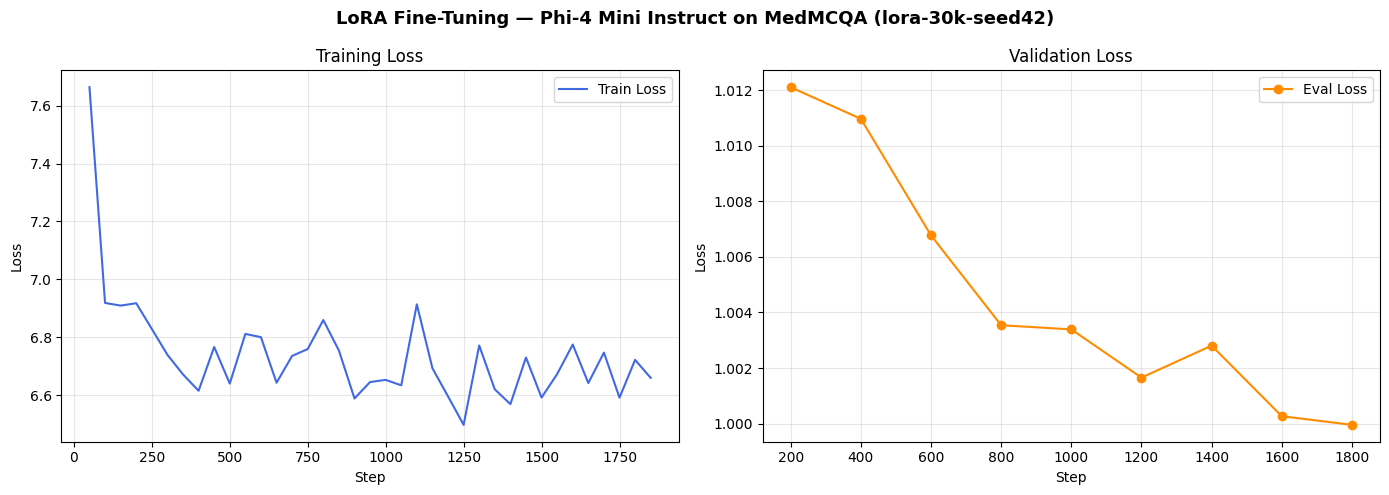

Saved training curve to: /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora-30k-seed42_training_curves.png


In [ ]:
# ============================================================
# 13 — Training Curve Visualisation
# ============================================================

import matplotlib.pyplot as plt

log_history = lora_trainer.state.log_history   # ← trainer → lora_trainer

# Separate train loss and eval loss entries
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_steps  = [x["step"]      for x in train_logs]
train_losses = [x["loss"]      for x in train_logs]
eval_steps   = [x["step"]      for x in eval_logs]
eval_losses  = [x["eval_loss"] for x in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"LoRA Fine-Tuning — Phi-4 Mini Instruct on MedMCQA ({run_name})", fontsize=13, fontweight="bold")

# Training loss
axes[0].plot(train_steps, train_losses, color="royalblue", linewidth=1.5, label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Eval loss
axes[1].plot(eval_steps, eval_losses, color="darkorange", linewidth=1.5, marker="o", label="Eval Loss")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plot_path = os.path.join(METRICS_DIR, f"{run_name}_training_curves.png")  # ← run_name in filename
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curve to: {plot_path}")

##VRAM & Efficiency Metrics

In [ ]:
# ============================================================
# 14 — VRAM & Efficiency Metrics
# ============================================================

efficiency_metrics = {}

if torch.cuda.is_available():
    efficiency_metrics["gpu_name"]             = torch.cuda.get_device_name(0)
    efficiency_metrics["vram_total_gb"]        = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
    efficiency_metrics["vram_peak_train_gb"]   = round(peak_vram, 2)
    efficiency_metrics["vram_after_train_gb"]  = round(post_vram, 2)

efficiency_metrics["run_name"]             = run_name
efficiency_metrics["method"]               = "LoRA"
efficiency_metrics["quantization"]         = "none"
efficiency_metrics["base_model_dtype"]     = "float16"
efficiency_metrics["trainable_params"]     = trainable
efficiency_metrics["total_params"]         = all_params
efficiency_metrics["trainable_pct"]        = round(100 * trainable / all_params, 4)
efficiency_metrics["train_samples"]        = len(train_sample)
efficiency_metrics["eval_samples"]         = len(eval_sample)
efficiency_metrics["train_time_mins"]      = round(train_time_mins, 2)
efficiency_metrics["num_train_epochs"]     = lora_args.num_train_epochs        # training_args → lora_args
efficiency_metrics["effective_batch_size"] = (lora_args.per_device_train_batch_size *   # training_args → lora_args
                                              lora_args.gradient_accumulation_steps)
efficiency_metrics["learning_rate"]        = lora_args.learning_rate
efficiency_metrics["seed"]                 = lora_args.seed

print("LoRA Efficiency Metrics:")
for k, v in efficiency_metrics.items():
    print(f"  {k:<30}: {v}")

eff_path = os.path.join(METRICS_DIR, f"{run_name}_efficiency_metrics.json")  # run_name in filename
with open(eff_path, "w") as f:
    json.dump(efficiency_metrics, f, indent=2)

print(f"\nSaved efficiency metrics to: {eff_path}")

LoRA Efficiency Metrics:
  gpu_name                      : NVIDIA A100-SXM4-80GB
  vram_total_gb                 : 85.09
  vram_peak_train_gb            : 11.31
  vram_after_train_gb           : 7.8
  run_name                      : lora-30k-seed42
  method                        : LoRA
  quantization                  : none
  base_model_dtype              : float16
  trainable_params              : 8912896
  total_params                  : 3844934656
  trainable_pct                 : 0.2318
  train_samples                 : 30000
  eval_samples                  : 1000
  train_time_mins               : 68.37
  num_train_epochs              : 1
  effective_batch_size          : 16
  learning_rate                 : 0.0002
  seed                          : 42

Saved efficiency metrics to: /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora-30k-seed42_efficiency_metrics.json


##Reload LoRA Model for Evaluation

In [ ]:
# ============================================================
# 15 — Reload LoRA Model for Evaluation
# ============================================================

print("Reloading base model for evaluation...")
lora_base_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,      # ← bfloat16 → float16 (matches fp16=True in lora_args)
    device_map="auto",
    trust_remote_code=True,
)

print(f"Loading LoRA adapter from: {LORA_SAVE_DIR}")
lora_eval_model = PeftModel.from_pretrained(lora_base_eval, LORA_SAVE_DIR)
lora_eval_model.eval()

print("\nModel loaded and set to eval mode.")
print(f"Run       : {run_name}")
print(f"Adapter   : {LORA_SAVE_DIR}")
if torch.cuda.is_available():
    print(f"VRAM after reload: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Reloading base model for evaluation...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapter from: /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2

Model loaded and set to eval mode.
Run       : lora-30k-seed42
Adapter   : /content/drive/MyDrive/phi4_medmcqa/lora_adapter_2
VRAM after reload: 15.50 GB


##Evaluation on Full Validation Set

In [ ]:
# ============================================================
# 16 — Logit-Based Evaluation on Full Validation Set
# ============================================================

# ── Prompt builder ───────────────────────────────────────────
def build_eval_prompt(example):
    return (
        "You are a medical expert answering a multiple choice medical question.\n"
        "Read the question carefully and select the single best option.\n"
        "Reply with only one letter: A, B, C, or D.\n\n"
        f"Question: {example['question']}\n\n"
        "Options:\n"
        f"A) {example['opa']}\n"
        f"B) {example['opb']}\n"
        f"C) {example['opc']}\n"
        f"D) {example['opd']}\n\n"
        "Answer:"
    )

# ── Candidate token ids ───────────────────────────────────────
candidate_letters = ["A", "B", "C", "D"]
candidate_token_ids = {}

for letter in candidate_letters:
    ids = tokenizer.encode(letter, add_special_tokens=False)
    if len(ids) != 1:
        raise ValueError(f"Token for '{letter}' is not a single token: {ids}")
    candidate_token_ids[letter] = ids[0]

print("Candidate token ids:", candidate_token_ids)

# ── Prediction function ───────────────────────────────────────
def predict_letter_from_logits(model, tokenizer, example, max_length=512):
    prompt = build_eval_prompt(example)

    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        padding=False,
    )

    input_ids      = enc["input_ids"].to(lora_eval_model.device)
    attention_mask = enc["attention_mask"].to(lora_eval_model.device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    # Logits for the token immediately after "Answer:"
    next_token_logits = outputs.logits[0, -1, :]

    scores = {
        letter: next_token_logits[token_id].item()
        for letter, token_id in candidate_token_ids.items()
    }

    pred = max(scores, key=scores.get)
    return pred, scores

# ── Metrics helper ────────────────────────────────────────────
def compute_metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy"        : acc,
        "precision_macro" : precision,
        "recall_macro"    : recall,
        "f1_macro"        : f1,
    }

# ── Run evaluation ────────────────────────────────────────────
y_true = []
y_pred = []
inference_times = []

validation_data = filtered["validation"]   # ← raw_dataset → filtered
print(f"\nEvaluating LoRA [{run_name}] on full validation set: {len(validation_data)} samples")

eval_start = time.time()

for i, ex in enumerate(tqdm(validation_data)):
    true_label = label_map[ex["cop"]]

    t0 = time.time()
    pred_label, scores = predict_letter_from_logits(lora_eval_model, tokenizer, ex)
    t1 = time.time()
    inference_times.append(t1 - t0)

    y_true.append(true_label)
    y_pred.append(pred_label)

    if i < 5:
        print(f"Sample {i} | Pred: {pred_label} | GT: {true_label} | Scores: {scores}")

eval_end = time.time()
total_eval_mins = (eval_end - eval_start) / 60

# ── Final metrics ─────────────────────────────────────────────
lora_metrics = compute_metrics_from_preds(y_true, y_pred)

lora_metrics["avg_inference_time_sec"]  = round(np.mean(inference_times), 4)
lora_metrics["total_eval_time_mins"]    = round(total_eval_mins, 2)
lora_metrics["method"]                  = "LoRA"
lora_metrics["run_name"]                = run_name                 # ← added
lora_metrics["train_samples"]           = len(train_sample)        # ← added
lora_metrics["learning_rate"]           = lora_args.learning_rate  # ← added

print(f"\nLoRA Validation Metrics [{run_name}]:")
print(lora_metrics)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

Candidate token ids: {'A': 32, 'B': 33, 'C': 34, 'D': 35}

Evaluating LoRA [lora-30k-seed42] on full validation set: 4183 samples


  0%|          | 2/4183 [00:00<04:57, 14.05it/s]

Sample 0 | Pred: A | GT: A | Scores: {'A': 40.5625, 'B': 38.375, 'C': 36.28125, 'D': 39.25}
Sample 1 | Pred: B | GT: A | Scores: {'A': 36.25, 'B': 38.21875, 'C': 36.09375, 'D': 35.90625}


  0%|          | 4/4183 [00:00<04:25, 15.75it/s]

Sample 2 | Pred: A | GT: C | Scores: {'A': 43.5, 'B': 42.28125, 'C': 42.90625, 'D': 43.28125}
Sample 3 | Pred: C | GT: C | Scores: {'A': 40.78125, 'B': 40.375, 'C': 42.53125, 'D': 38.0}


  0%|          | 6/4183 [00:00<04:12, 16.52it/s]

Sample 4 | Pred: A | GT: A | Scores: {'A': 40.125, 'B': 39.34375, 'C': 37.6875, 'D': 38.1875}


100%|██████████| 4183/4183 [03:54<00:00, 17.86it/s]



LoRA Validation Metrics [lora-30k-seed42]:
{'accuracy': 0.5235476930432704, 'precision_macro': 0.5693965239866917, 'recall_macro': 0.5154478908279043, 'f1_macro': 0.5186542081591644, 'avg_inference_time_sec': np.float64(0.0553), 'total_eval_time_mins': 3.9, 'method': 'LoRA', 'run_name': 'lora-30k-seed42', 'train_samples': 30000, 'learning_rate': 0.0002}

Classification Report:
              precision    recall  f1-score   support

           A       0.59      0.49      0.53      1348
           B       0.42      0.74      0.53      1085
           C       0.64      0.42      0.51       925
           D       0.63      0.41      0.50       825

    accuracy                           0.52      4183
   macro avg       0.57      0.52      0.52      4183
weighted avg       0.56      0.52      0.52      4183



##Save Evaluation Metrics

In [ ]:
# ============================================================
# 17 — Save Evaluation Metrics
# ============================================================

os.makedirs(METRICS_DIR, exist_ok=True)

# Full validation metrics
val_metrics_path = os.path.join(METRICS_DIR, "lora_full_validation_metrics.json")
with open(val_metrics_path, "w") as f:
    json.dump(lora_metrics, f, indent=2)

# Per-sample predictions (useful for error analysis)
predictions_path = os.path.join(METRICS_DIR, "lora_predictions.json")
predictions_data = [
    {"index": i, "true": t, "pred": p, "correct": t == p}
    for i, (t, p) in enumerate(zip(y_true, y_pred))
]
with open(predictions_path, "w") as f:
    json.dump(predictions_data, f, indent=2)

print("Saved:")
print(f"  Validation metrics : {val_metrics_path}")
print(f"  Per-sample preds   : {predictions_path}")

Saved:
  Validation metrics : /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora_full_validation_metrics.json
  Per-sample preds   : /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora_predictions.json


##LoRA vs QLoRA Comparison Table (Cross-Run)

In [ ]:
# ============================================================
# 18 — LoRA vs QLoRA Comparison Table
# ============================================================
# Run AFTER both notebooks have completed.
# Loads QLoRA metrics from the QLoRA run's metrics directory
# and prints a side-by-side comparison.
# ============================================================

QLORA_METRICS_DIR = os.path.join(BASE_DIR, "metrics_1")
qlora_metrics_path = os.path.join(QLORA_METRICS_DIR, "qlora_full_validation_metrics.json")

comparison_rows = []

# LoRA row (current run)
comparison_rows.append({
    "Method"            : "LoRA",
    "Quantization"      : "None (bf16)",
    "Accuracy"          : round(lora_metrics["accuracy"], 4),
    "F1 (Macro)"        : round(lora_metrics["f1_macro"], 4),
    "Precision (Macro)" : round(lora_metrics["precision_macro"], 4),
    "Recall (Macro)"    : round(lora_metrics["recall_macro"], 4),
    "Avg Infer (s)"     : round(lora_metrics.get("avg_inference_time_sec", 0), 4),
    "Peak VRAM (GB)"    : efficiency_metrics.get("vram_peak_train_gb", "N/A"),
    "Train Time (min)"  : efficiency_metrics.get("train_time_mins", "N/A"),
})

# QLoRA row (from saved file)
if os.path.exists(qlora_metrics_path):
    with open(qlora_metrics_path) as f:
        qm = json.load(f)
    comparison_rows.append({
        "Method"            : "QLoRA",
        "Quantization"      : "4-bit NF4",
        "Accuracy"          : round(qm["accuracy"], 4),
        "F1 (Macro)"        : round(qm["f1_macro"], 4),
        "Precision (Macro)" : round(qm["precision_macro"], 4),
        "Recall (Macro)"    : round(qm["recall_macro"], 4),
        "Avg Infer (s)"     : "see QLoRA notebook",
        "Peak VRAM (GB)"    : "see QLoRA notebook",
        "Train Time (min)"  : "see QLoRA notebook",
    })
else:
    print(f"QLoRA metrics not found at: {qlora_metrics_path}")
    print("Run the QLoRA notebook first, then re-run this cell.")

df_compare = pd.DataFrame(comparison_rows)
print("\n=== LoRA vs QLoRA Comparison ===")
print(df_compare.to_string(index=False))

# Save comparison table
compare_csv_path = os.path.join(METRICS_DIR, "lora_vs_qlora_comparison.csv")
df_compare.to_csv(compare_csv_path, index=False)
print(f"\nSaved comparison table to: {compare_csv_path}")


=== LoRA vs QLoRA Comparison ===
Method Quantization  Accuracy  F1 (Macro)  Precision (Macro)  Recall (Macro)      Avg Infer (s)     Peak VRAM (GB)   Train Time (min)
  LoRA  None (bf16)    0.5235      0.5187             0.5694          0.5154             0.0553              11.31              68.37
 QLoRA    4-bit NF4    0.5463      0.5404             0.5473          0.5367 see QLoRA notebook see QLoRA notebook see QLoRA notebook

Saved comparison table to: /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora_vs_qlora_comparison.csv


## 19 — Subject-Level Accuracy Analysis

Subject-Level Accuracy (LoRA):
  Pharmacology                                 : 0.658  (n=243)
  Pathology                                    : 0.638  (n=337)
  Biochemistry                                 : 0.637  (n=171)
  Microbiology                                 : 0.631  (n=122)
  ENT                                          : 0.566  (n=53)
  Psychiatry                                   : 0.562  (n=16)
  Medicine                                     : 0.549  (n=295)
  Physiology                                   : 0.544  (n=171)
  Pediatrics                                   : 0.543  (n=234)
  Social & Preventive Medicine                 : 0.543  (n=129)
  Anatomy                                      : 0.534  (n=234)
  Surgery                                      : 0.531  (n=369)
  Radiology                                    : 0.507  (n=69)
  Ophthalmology                                : 0.466  (n=58)
  Dental                                       : 0.453  (n=1318)
  Gynaecolog

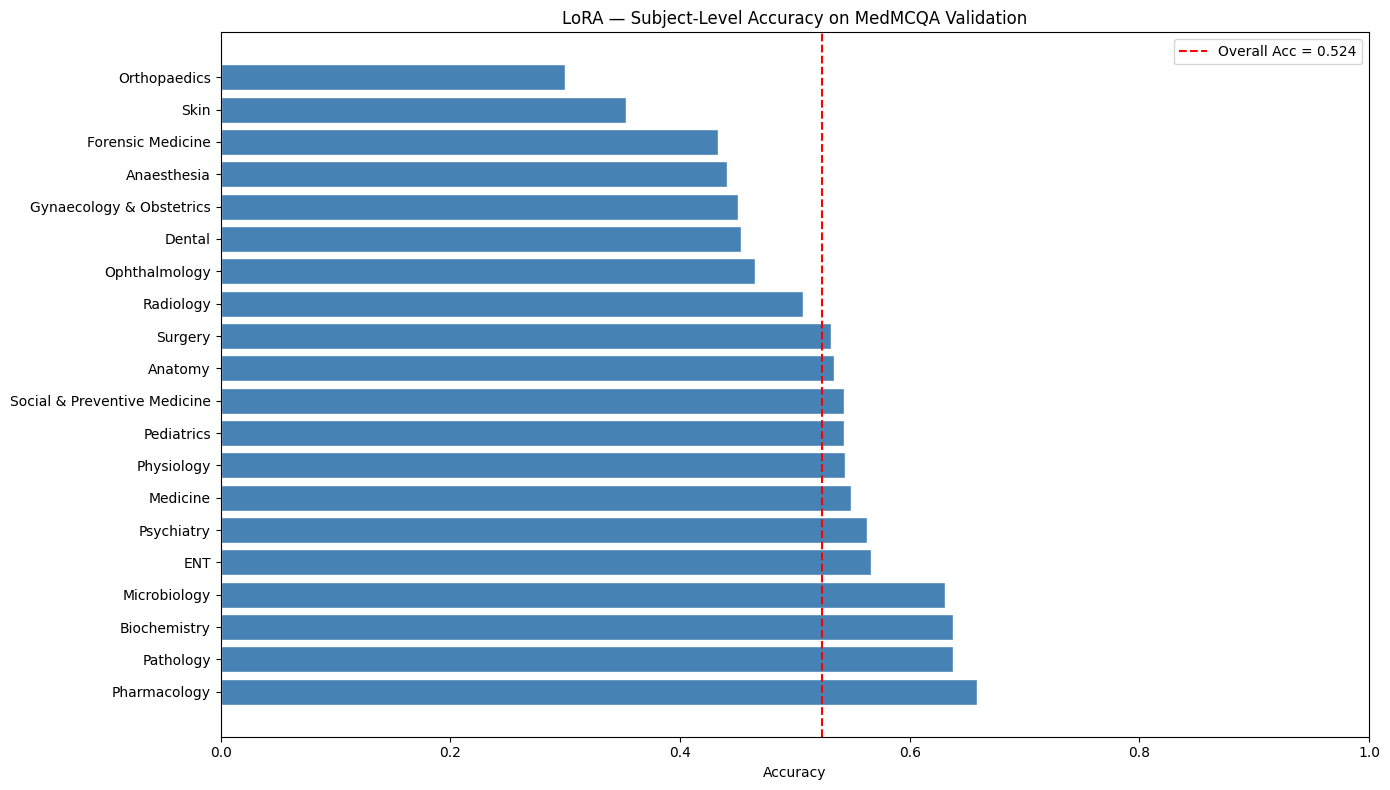

Saved subject accuracy chart to: /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora_subject_accuracy.png
Saved subject accuracy JSON to: /content/drive/MyDrive/phi4_medmcqa/metrics_lora_2/lora_subject_accuracy.json


In [ ]:
# ============================================================
# 19 — Subject-Level Accuracy Analysis
# ============================================================
# Breaks down performance by medical subject for deeper
# error analysis — maps to research objective of assessing
# subject-wise consistency.
# ============================================================

import matplotlib.pyplot as plt

validation_data = filtered["validation"]

# Build subject -> (correct, total) dict
subject_results = {}
for i, ex in enumerate(validation_data):
    subj = ex.get("subject_name", "Unknown")
    correct = (y_pred[i] == y_true[i])
    if subj not in subject_results:
        subject_results[subj] = {"correct": 0, "total": 0}
    subject_results[subj]["correct"] += int(correct)
    subject_results[subj]["total"]   += 1

# Compute accuracy per subject
subj_acc = {
    subj: v["correct"] / v["total"]
    for subj, v in subject_results.items()
    if v["total"] >= 10   # only subjects with >= 10 samples
}

# Sort by accuracy
sorted_subj = dict(sorted(subj_acc.items(), key=lambda x: x[1], reverse=True))

print("Subject-Level Accuracy (LoRA):")
for subj, acc in sorted_subj.items():
    n = subject_results[subj]["total"]
    print(f"  {subj:<45}: {acc:.3f}  (n={n})")

# Plot
fig, ax = plt.subplots(figsize=(14, max(6, len(sorted_subj) * 0.4)))
subjects = list(sorted_subj.keys())
accs     = list(sorted_subj.values())

bars = ax.barh(subjects, accs, color="steelblue", edgecolor="white")
ax.axvline(x=lora_metrics["accuracy"], color="red", linestyle="--", label=f"Overall Acc = {lora_metrics['accuracy']:.3f}")
ax.set_xlabel("Accuracy")
ax.set_title("LoRA — Subject-Level Accuracy on MedMCQA Validation")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()

subj_plot_path = os.path.join(METRICS_DIR, "lora_subject_accuracy.png")
plt.savefig(subj_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved subject accuracy chart to: {subj_plot_path}")

# Save as JSON
subj_json_path = os.path.join(METRICS_DIR, "lora_subject_accuracy.json")
with open(subj_json_path, "w") as f:
    json.dump({s: round(a, 4) for s, a in sorted_subj.items()}, f, indent=2)
print(f"Saved subject accuracy JSON to: {subj_json_path}")

##Optional: Merge LoRA Adapter into Base Model

In [ ]:
# ============================================================
# 20 — Optional: Merge LoRA Adapter into Base Model
# ============================================================
# Merging fuses the adapter weights into the base model,
# producing a single standalone model for faster inference
# (no adapter overhead at runtime).
#
# NOTE: merge_and_unload() requires the model to be in
# full precision (bf16/fp16). It does NOT work with QLoRA's
# 4-bit quantized base — this is a LoRA-exclusive step.
#
# Merged model size: ~8 GB (same as the bf16 base model)
# Saving requires sufficient Drive space.
# ============================================================

MERGE_ENABLED = False   # ← set True to merge and save

if MERGE_ENABLED:
    print("Merging LoRA adapter weights into base model...")
    merged_model = lora_eval_model.merge_and_unload()

    print(f"Saving merged model to: {LORA_FINAL_DIR}")
    merged_model.save_pretrained(LORA_FINAL_DIR)
    tokenizer.save_pretrained(LORA_FINAL_DIR)

    print("Merged model saved. Files:")
    for fname in sorted(os.listdir(LORA_FINAL_DIR)):
        size_mb = os.path.getsize(os.path.join(LORA_FINAL_DIR, fname)) / 1e6
        print(f"  {fname}  ({size_mb:.0f} MB)")
else:
    print("Merge skipped (MERGE_ENABLED=False).")
    print("Set MERGE_ENABLED=True if you want a standalone merged model.")

Merge skipped (MERGE_ENABLED=False).
Set MERGE_ENABLED=True if you want a standalone merged model.


##Release GPU Memory & Unassign Runtime

In [ ]:
# ============================================================
# 21 — Release GPU Memory
# ============================================================

import gc

del lora_eval_model
del lora_base_eval
del lora_model
del base_model

gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("\nAll models released from memory.")
print("LoRA fine-tuning complete.")

VRAM after cleanup: 7.80 GB

All models released from memory.
LoRA fine-tuning complete. ✅


In [ ]:
from google.colab import runtime
runtime.unassign()